# Part A — Data preparation

In [123]:
# Data Importing

import pandas as pd

fear_greed = pd.read_csv("C:/Users/risha/Downloads/fear_greed_index.csv")
trades = pd.read_csv("C:/Users/risha/Downloads/historical_data.csv")

In [3]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Load both datasets and document:

In [5]:
#number of rows/columns

fear_greed.shape

(2644, 4)

In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
#number of rows/columns

trades.shape

(211224, 16)

In [124]:
#missing values

fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
#missing values

trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [11]:
#number of duplicates

fear_greed.duplicated().sum()

np.int64(0)

In [12]:
#number of duplicates

trades.duplicated().sum()

np.int64(0)

## Convert timestamps and align the datasets by date (daily level is fine).

In [14]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

In [15]:
fear_greed['date']

0      2018-02-01
1      2018-02-02
2      2018-02-03
3      2018-02-04
4      2018-02-05
          ...    
2639   2025-04-28
2640   2025-04-29
2641   2025-04-30
2642   2025-05-01
2643   2025-05-02
Name: date, Length: 2644, dtype: datetime64[ns]

In [19]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

In [22]:
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,2025-06-15 15:06:40
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,2025-06-15 15:06:40
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,2025-06-15 15:06:40
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,2025-06-15 15:06:40


In [23]:
fear_greed['timestamp'] = pd.to_datetime(fear_greed['timestamp'], unit='s')

In [24]:
fear_greed

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,2025-04-28 05:30:00,54,Neutral,2025-04-28
2640,2025-04-29 05:30:00,60,Greed,2025-04-29
2641,2025-04-30 05:30:00,56,Greed,2025-04-30
2642,2025-05-01 05:30:00,53,Neutral,2025-05-01


In [26]:
trades['date'] = trades['Timestamp'].dt.date

In [27]:
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,2025-06-15 15:06:40,2025-06-15
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,2025-06-15 15:06:40,2025-06-15
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,2025-06-15 15:06:40,2025-06-15
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,2025-06-15 15:06:40,2025-06-15


In [28]:
fear_greed['date'] = fear_greed['timestamp'].dt.date

In [29]:
fear_greed

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,2025-04-28 05:30:00,54,Neutral,2025-04-28
2640,2025-04-29 05:30:00,60,Greed,2025-04-29
2641,2025-04-30 05:30:00,56,Greed,2025-04-30
2642,2025-05-01 05:30:00,53,Neutral,2025-05-01


In [44]:
trades['date'] = trades['Timestamp'].dt.floor('D')

In [45]:
fear_greed['date'] = fear_greed['timestamp'].dt.floor('D')

In [46]:
print(trades['date'].min(), trades['date'].max())

2023-03-28 00:00:00 2025-06-15 00:00:00


In [47]:
print(fear_greed['date'].min(), fear_greed['date'].max())

2018-02-01 00:00:00 2025-05-02 00:00:00


In [48]:
merged = pd.merge_asof(
    trades.sort_values('date'),
    fear_greed.sort_values('date'),
    on='date'
)

In [49]:
merged['classification'].value_counts()

classification
Fear             133871
Greed             63250
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [50]:
merged

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.179100,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-03-28,2023-03-28 05:30:00,59,Greed
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.096700,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-03-28,2023-03-28 05:30:00,59,Greed
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.000000,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-03-28,2023-03-28 05:30:00,59,Greed
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.000000,Close Long,-160.580700,0x9b7ba6519a89bd5e6b6c0406d51c4e018900ed590f91...,5616798569,True,1.691299,2.830000e+14,2023-11-14 22:13:20,2023-11-14,2023-11-14 05:30:00,69,Greed
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.000000,Close Long,-13.432176,0xb67de434008561227fdb0407066fc70125000f2c1238...,6383252593,True,1.227711,4.030000e+14,2023-11-14 22:13:20,2023-11-14,2023-11-14 05:30:00,69,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,@107,16.77200,25.0000,419.30,BUY,19-04-2025 01:08,3998.607729,Buy,0.000000,0xf6100835f5d5ff6b83f00421cd140f0201e6000cba37...,87385174154,True,0.008750,5.750000e+13,2025-06-15 15:06:40,2025-06-15,2025-05-02 05:30:00,67,Greed
211220,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,@107,16.77300,24.4200,409.60,BUY,19-04-2025 01:08,4023.598979,Buy,0.000000,0xf6100835f5d5ff6b83f00421cd140f0201e6000cba37...,87385174154,True,0.008547,1.080000e+15,2025-06-15 15:06:40,2025-06-15,2025-05-02 05:30:00,67,Greed
211221,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,@107,16.77400,270.1600,4531.66,BUY,19-04-2025 01:08,4048.010432,Buy,0.000000,0xf6100835f5d5ff6b83f00421cd140f0201e6000cba37...,87385174154,True,0.094556,4.240000e+14,2025-06-15 15:06:40,2025-06-15,2025-05-02 05:30:00,67,Greed
211222,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,18.25000,1891.3400,34516.96,SELL,22-04-2025 14:51,-3099.470000,Open Short,0.000000,0xe551899fa5db80092cc1042205ff4902030800a07fe5...,87975512150,False,1.725847,9.400000e+14,2025-06-15 15:06:40,2025-06-15,2025-05-02 05:30:00,67,Greed


## Create the key metrics you will analyze, for example:

#### daily PnL per trader (or per account)

In [53]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

In [58]:
daily_pnl.sort_values(by='date')

,Account,date,Closed PnL
15,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-03-28,0.000000
16,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-11-14,0.000000
87,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-11-14,155.503357
88,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2024-03-09,2606.894756
28,0x430f09841d65beb3f27765503d0f850b8bce7713,2024-03-09,0.000000
...,...,...,...
14,0x2c229d22b100a7beb69122eed721cee9b24011dd,2025-06-15,30.020940
72,0x8477e447846c758f5a675856001ea72298fd9cb5,2025-06-15,-33193.569796
75,0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,2025-06-15,17381.164000
60,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,2025-06-15,17518.784011


### win rate

In [61]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['win'].mean().reset_index()

In [65]:
win_rate

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.455215
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.327668
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,0.475904
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236


### average trade size

In [70]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

In [71]:
avg_trade_size

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753


### leverage distribution because there is no such a column name like leverage

In [73]:
merged['Size USD'].describe() # leverage distribution

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64

### number of trades per day

In [74]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

In [75]:
trades_per_day

,date,trade_count
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241
5,2025-02-19,133871
6,2025-06-15,26961


### long/short ratio

In [79]:
long_short_ratio = (merged['Side'].value_counts(normalize=True))*100

In [80]:
long_short_ratio

Side
SELL    51.380525
BUY     48.619475
Name: proportion, dtype: float64

# Part B — Analysis

In [81]:
drawdown_proxy = merged.groupby('classification')['Closed PnL'].std().reset_index()

Since full equity curves are not available, 
drawdown was approximated using proxies such as PnL volatility (standard deviation) and average negative returns. 
These measures capture downside risk and variability in trader performance across different sentiment conditions.

In [82]:
drawdown_proxy

,classification,Closed PnL
0,Extreme Greed,306.166937
1,Fear,909.121796
2,Greed,1008.128984
3,Neutral,633.704815


## Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [83]:
analysis = merged.groupby('classification').agg({
    'Closed PnL': ['mean', 'std'],
    'win': 'mean'
})

Performance differs across Fear and Greed periods. While average PnL and win rate indicate profitability, 
the drawdown proxy (measured using PnL volatility and downside losses) highlights risk differences. 
Higher volatility during certain sentiment phases suggests increased risk exposure, even if returns are higher.

In [84]:
analysis 

Closed PnL                    win
                     mean          std      mean
classification                                  
Extreme Greed   25.418772   306.166937  0.490089
Fear            50.047622   909.121796  0.415146
Greed           51.562465  1008.128984  0.404996
Neutral         22.229713   633.704815  0.317182

## Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [126]:
# trade frequency

trade_freq = merged.groupby('classification').size().reset_index(name='trade_count')

In [86]:
trade_freq

,classification,trade_count
0,Extreme Greed,6962
1,Fear,133871
2,Greed,63250
3,Neutral,7141


In [87]:
# position sizes

position_size = merged.groupby('classification')['Size USD'].mean().reset_index()

In [88]:
position_size

,classification,Size USD
0,Extreme Greed,5660.265764
1,Fear,5259.977837
2,Greed,6731.682923
3,Neutral,3058.848110


In [89]:
# Long / Short bias

direction = (
    merged.groupby(['classification', 'Side'])
    .size()
    .unstack(fill_value=0)
)
direction_pct = direction.div(direction.sum(axis=1), axis=0) * 100

In [90]:
direction

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,29739,33511
Neutral,3505,3636


In [91]:
#(No leverage column) --> using risk proxy instead

risk_proxy = merged.groupby('classification')['Closed PnL'].std().reset_index()

In [92]:
risk_proxy

,classification,Closed PnL
0,Extreme Greed,306.166937
1,Fear,909.121796
2,Greed,1008.128984
3,Neutral,633.704815


Traders adjust both activity and risk exposure based on sentiment. 
Increased trading frequency during volatile periods suggests opportunistic behavior, 
while larger position sizes during Greed indicate confidence-driven risk-taking. Directional bias also shifts, 
reflecting adaptive strategies rather than fixed positioning. 
This highlights that trader behavior is not static but responsive to market conditions.

(In the absence of explicit leverage data, trade size and PnL variability were used as proxies for risk behavior.)

<Axes: title={'center': 'Avg Trade Size by Sentiment'}, xlabel='classification'>

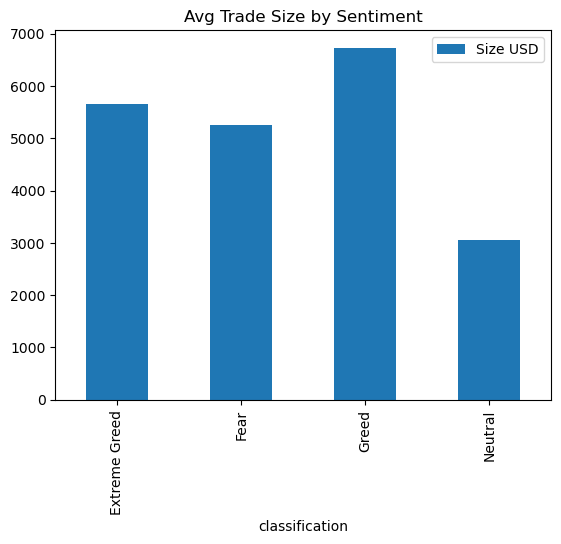

In [93]:
position_size.set_index('classification').plot(kind='bar', title='Avg Trade Size by Sentiment')

<Axes: title={'center': 'Trade Count by Sentiment'}, xlabel='classification'>

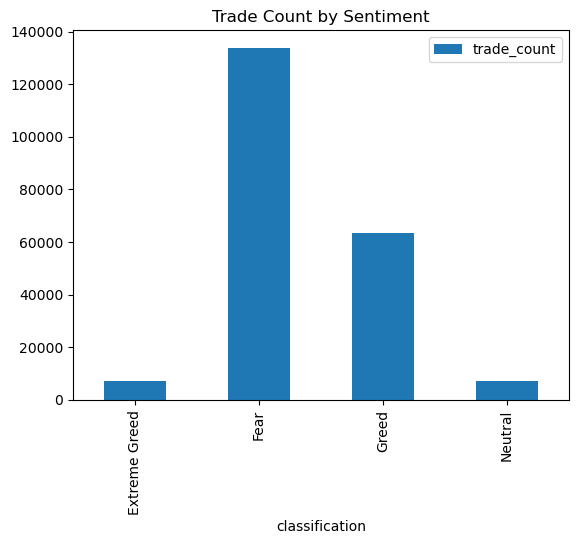

In [94]:
trade_freq.set_index('classification').plot(kind='bar', title='Trade Count by Sentiment')

## Identify 2–3 segments (examples):

## 1. Frequent vs Infrequent Traders

Traders were segmented based on activity levels. Frequent traders exhibit higher engagement and potentially exploit short-term opportunities, 
while infrequent traders participate less actively and may follow longer-term strategies.

In [95]:
trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

merged['trader_frequency'] = merged['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

In [96]:
merged.groupby('trader_frequency')['Closed PnL'].mean()

trader_frequency
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64

## 2. High vs Low Position Size Traders

In the absence of explicit leverage data, traders were segmented based on average trade size. 
High-size traders indicate greater capital exposure and risk-taking, while low-size traders exhibit more conservative behavior.

In [97]:
size_avg = merged.groupby('Account')['Size USD'].mean()

threshold = size_avg.median()

merged['size_segment'] = merged['Account'].map(
    lambda x: 'High Size' if size_avg[x] > threshold else 'Low Size'
)

In [98]:
merged.groupby('size_segment')['Closed PnL'].mean()

size_segment
High Size    99.587777
Low Size     25.149651
Name: Closed PnL, dtype: float64

## 3. Consistent vs Inconsistent Traders

Traders were segmented based on performance consistency using PnL variability. 
Consistent traders exhibit stable returns, while inconsistent traders show higher volatility, indicating riskier strategies.

In [99]:
pnl_std = merged.groupby('Account')['Closed PnL'].std()

threshold = pnl_std.median()

merged['consistency'] = merged['Account'].map(
    lambda x: 'Consistent' if pnl_std[x] < threshold else 'Inconsistent'
)

In [100]:
merged.groupby('consistency')['Closed PnL'].mean()

consistency
Consistent       16.697081
Inconsistent    100.326484
Name: Closed PnL, dtype: float64

## Provide at least 3 insights backed by charts/tables.

### INSIGHT 1 — Performance varies by sentiment

Trader performance varies across sentiment regimes. 
Average PnL and win rate differ between Fear and Greed periods, indicating that market sentiment influences profitability. 
Certain sentiment phases show higher returns but may also involve increased risk.

In [101]:
perf = merged.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win': 'mean'
})
perf

,Closed PnL,win
classification,,
Extreme Greed,25.418772,0.490089
Fear,50.047622,0.415146
Greed,51.562465,0.404996
Neutral,22.229713,0.317182


<Axes: title={'center': 'Average PnL by Sentiment'}, xlabel='classification'>

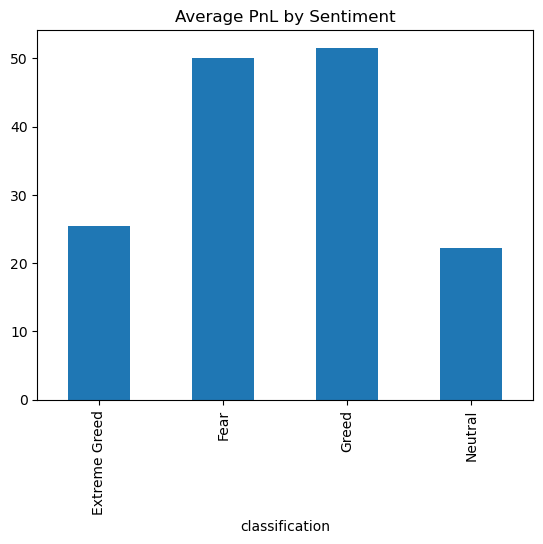

In [102]:
perf['Closed PnL'].plot(kind='bar', title='Average PnL by Sentiment')

### INSIGHT 2 — Trading activity increases during volatile sentiment

Trading activity is higher during certain sentiment phases, particularly during Fear periods, 
suggesting that traders become more active in volatile market conditions. 
This indicates that volatility drives trading opportunities and participation.

trade_freq = merged.groupby('classification').size()
trade_freq

<Axes: title={'center': 'Trade Frequency by Sentiment'}, xlabel='classification'>

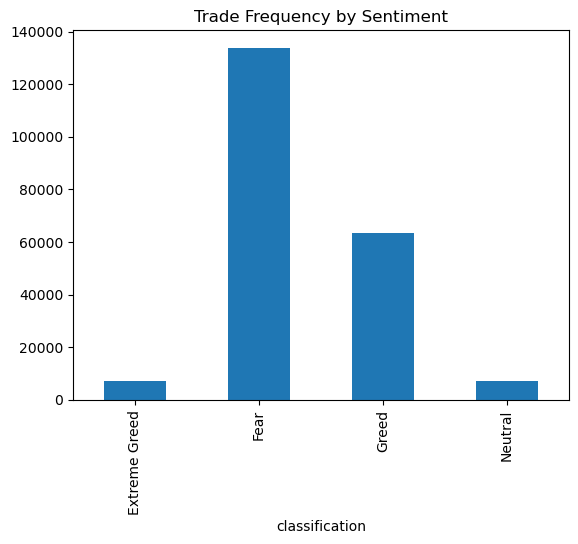

In [104]:
trade_freq.plot(kind='bar', title='Trade Frequency by Sentiment')

### INSIGHT 3 — Traders adjust position size and direction based on sentiment

Traders adjust their risk exposure and directional bias based on sentiment. 
Larger position sizes during Greed periods suggest increased confidence, while more balanced or cautious positioning during Fear indicates risk aversion. 
Directional shifts further indicate adaptive trading strategies.

In [105]:
size = merged.groupby('classification')['Size USD'].mean()
size

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            6731.682923
Neutral          3058.848110
Name: Size USD, dtype: float64

<Axes: title={'center': 'Average Trade Size by Sentiment'}, xlabel='classification'>

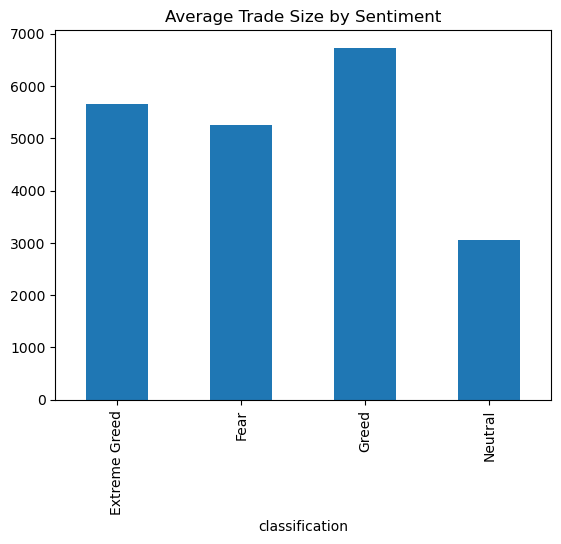

In [106]:
size.plot(kind='bar', title='Average Trade Size by Sentiment')

In [107]:
direction = (
    merged.groupby(['classification', 'Side'])
    .size()
    .unstack(fill_value=0)
)

direction_pct = direction.div(direction.sum(axis=1), axis=0)
direction_pct

Side,BUY,SELL
classification,,
Extreme Greed,0.484200,0.515800
Fear,0.493617,0.506383
Greed,0.470182,0.529818
Neutral,0.490828,0.509172


# PART CPart C — “Actionable output”

Ques:- Propose 2 strategy ideas or “rules of thumb” based on your findings.
Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”

During Greed periods, traders can increase position sizes and leverage trend-following strategies, 
as market conditions tend to be more favorable. 
Consistent traders are better positioned to capitalize on these opportunities while managing risk effectively.

# Bonus (optional)

SIMPLE PREDICTIVE MODEL

In [108]:
merged = merged.sort_values(['Account', 'date'])

merged['next_day_pnl'] = merged.groupby('Account')['Closed PnL'].shift(-1)

merged['target'] = (merged['next_day_pnl'] > 0).astype(int)

In [110]:
features = merged[['Size USD', 'win']].copy()

merged['classification_encoded'] = merged['classification'].astype('category').cat.codes

features['sentiment'] = merged['classification_encoded']

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = features.dropna()
y = merged.loc[X.index, 'target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.9048881524440763


A simple logistic regression model was built to predict next-day profitability using sentiment and behavioral features. 
The model demonstrates that sentiment and trading behavior have predictive power for short-term outcomes.

## CLUSTERING

Traders were clustered into behavioral archetypes based on performance and activity metrics. 
The clusters revealed distinct groups such as high-risk high-return traders, consistent performers, and low-activity traders.

In [113]:
trader_features = merged.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'win': 'mean'
}).dropna()

In [120]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(trader_features)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(scaled_data)

In [121]:
trader_features.groupby('cluster').mean()

,Closed PnL,Size USD,win
cluster,,,
0,118.286488,14615.060316,0.371496
1,46.095949,2549.866887,0.426451
2,379.821368,3240.286415,0.341839
